# Heat Generation Interpolation Example

This notebook demonstrates interpolating volumetric heat generation values from source to destination mesh using the CLOSEST kernel with k=4 nearest neighbors.

In [7]:
from interpcore.interpolator import Interpolator
from interpcore.config import InterpolationConfig, QUERY_TYPE, INTERPOLATED_LOAD_TYPE
from interpcore.kernels import INTERPOLATION_KERNEL

## Configure and Run Interpolation

In [8]:
# Create configuration for CLOSEST kernel with HEAT_GEN load type
config = InterpolationConfig(
    method=QUERY_TYPE.K,
    param=4,
    max_distance=2.0,
    coincidence_tolerance=0.01,
    kernel=INTERPOLATION_KERNEL.CLOSEST,
    multithread=False,
    interpolated_load=INTERPOLATED_LOAD_TYPE.HEAT_GEN
)

# Define file column indices (including volume column for integral computation)
file_idx = {"ids": 0, "dest_x": 1, "src_x": 1, "val": 4, "vol": 4}

# Create interpolator
interpolator = Interpolator(
    path_to_src_folder="source_data",
    path_to_dest_mesh="destination_mesh.txt",
    config=config,
    file_idx=file_idx
)

# Run interpolation
interpolator.interpolate_all()
print("Interpolation completed!")

100%|██████████| 1/1 [00:00<00:00, 36.76it/s]

Interpolation completed!


## Export to APDL format

In [9]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as tmp_dir:
    interpolator.export_to_ansys(tmp_dir)

    # Preview the exported file content
    with open(f"{tmp_dir}/interpolated_heat_gen_data.txt", "r") as f:
        for line in f.readlines()[:5]:
            print(line.strip())

BFE, 401.0, HGEN,, 500.0
BFE, 402.0, HGEN,, 550.0
BFE, 403.0, HGEN,, 600.0
BFE, 404.0, HGEN,, 600.0
BFE, 405.0, HGEN,, 700.0


## View Results

Build VTK output for visualization of volumetric heat generation.

In [10]:
import pyvista as pv
import matplotlib.pyplot as plt

interpolator.build_vtk_output(outdir=None)

Visualize the heat generation fields as point clouds

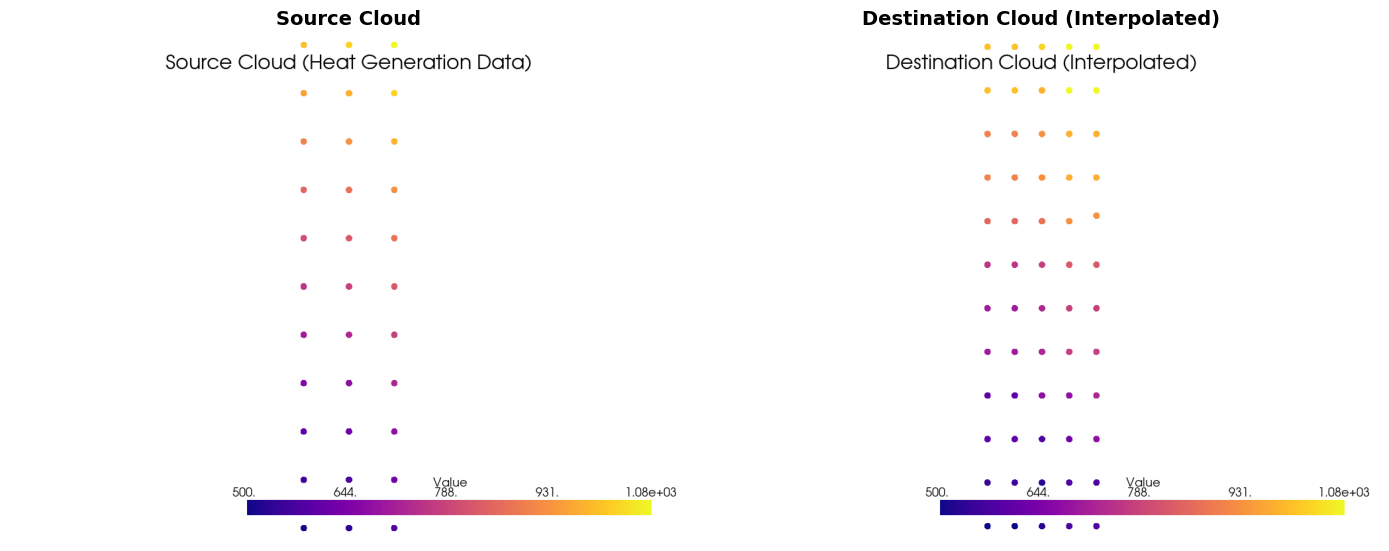

In [11]:
source_cloud = interpolator.src_vtk["heat_gen_data"]
dest_cloud = interpolator.dest_vtk["heat_gen_data"]

# Create a static plot comparing the two clouds side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot source cloud with gaussian points
plotter_src = pv.Plotter(off_screen=True)
plotter_src.add_mesh(source_cloud, scalars='Value', cmap='plasma', point_size=10, 
                     render_points_as_spheres=False, style='points')
plotter_src.add_title('Source Cloud (Heat Generation Data)', font_size=12)
plotter_src.camera_position = 'xy'
img_src = plotter_src.screenshot(return_img=True)
plotter_src.close()

# Plot destination cloud with gaussian points
plotter_dest = pv.Plotter(off_screen=True)
plotter_dest.add_mesh(dest_cloud, scalars='Value', cmap='plasma', point_size=10, 
                      render_points_as_spheres=False, style='points')
plotter_dest.add_title('Destination Cloud (Interpolated)', font_size=12)
plotter_dest.camera_position = 'xy'
img_dest = plotter_dest.screenshot(return_img=True)
plotter_dest.close()

# Display in matplotlib
axes[0].imshow(img_src)
axes[0].axis('off')
axes[0].set_title('Source Cloud', fontsize=14, fontweight='bold')

axes[1].imshow(img_dest)
axes[1].axis('off')
axes[1].set_title('Destination Cloud (Interpolated)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Compute Total Heat Generation Integral

Calculate the total heat generation over the destination mesh by integrating the scalar field.

In [12]:
# Compute the total heat generation integral over the volume
integrals = interpolator.compute_scalar_integrals()

print(f"{'='*60}")
print("Total Heat Generation Integrals")
print(f"{'='*60}")
for name, integral in integrals.items():
    print(f"\n{name}: {integral[0]:.6f} W (or units of heat_gen * volume)")

Total Heat Generation Integrals

heat_gen_data: 47.150000 W (or units of heat_gen * volume)
